# Plot conventional/unconventional eddies

#### Data import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import statsmodels.api as sm


In [2]:
#import data ac/c
edso1_clt_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

edso1_hfls_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfls_ac_q75_e20.nc")
edso1_hfls_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfls_c_q75_e20.nc")

edso1_hfss_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfss_ac_q75_e20.nc")
edso1_hfss_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfss_c_q75_e20.nc")

edso1_sfcwind_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_sfcwind_ac_q75_e20.nc")
edso1_sfcwind_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_sfcwind_c_q75_e20.nc")

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfls_ac_q75_e20.nc'

#### split into acw/acc/cw/cc

In [3]:
edso1_clt_ac_q75_e20_warm = edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst > 0, drop = True)
edso1_clt_ac_q75_e20_cold = edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst < 0, drop = True)
edso1_clt_c_q75_e20_warm = edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst > 0, drop = True)
edso1_clt_c_q75_e20_cold = edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst < 0, drop = True)

edso1_hfls_ac_q75_e20_warm = edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst > 0, drop = True)
edso1_hfls_ac_q75_e20_cold = edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst < 0, drop = True)
edso1_hfls_c_q75_e20_warm = edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst > 0, drop = True)
edso1_hfls_c_q75_e20_cold = edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst < 0, drop = True)

edso1_hfss_ac_q75_e20_warm = edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst > 0, drop = True)
edso1_hfss_ac_q75_e20_cold = edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst < 0, drop = True)
edso1_hfss_c_q75_e20_warm = edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst > 0, drop = True)
edso1_hfss_c_q75_e20_cold = edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst < 0, drop = True)

edso1_sfcwind_ac_q75_e20_warm = edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst > 0, drop = True)
edso1_sfcwind_ac_q75_e20_cold = edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst < 0, drop = True)
edso1_sfcwind_c_q75_e20_warm = edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst > 0, drop = True)
edso1_sfcwind_c_q75_e20_cold = edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst < 0, drop = True)

#### DOF Method

In [4]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

def run_effective_regression(ds, y_name, x_name, T=7, alpha=0.05):
    """
    Full pipeline:
    - compute effective sample size (n_eff = n / T)
    - run simple linear regression y ~ x
    - compute Pearson r and R²
    - return full OLS output
    - adjust SE, t, p, CI using n_eff
    - print results rounded to 4 decimals
    """

    #extract data
    ds_single = ds.isel(NbSample=0)
    df = ds_single.to_dataframe().reset_index()

    y = df[y_name]
    X = df[[x_name]]
    X = sm.add_constant(X)

    #effective sample size
    n = len(df)
    n_eff = n / T

    #fit OLS model
    model = sm.OLS(y, X).fit()
    ols_summary_text = model.summary().as_text()

    
    #pearson correlation and R²
    df_clean = df[[x_name, y_name]].dropna()
    r = np.corrcoef(df_clean[x_name], df_clean[y_name])[0, 1]

    R2 = r**2

    #adjust interference
    b = model.params[x_name]
    se_orig = model.bse[x_name]
    k = X.shape[1]

    se_new = se_orig * np.sqrt(n / n_eff)
    t_new = b / se_new
    df_eff = n_eff - k
    p_new = 2 * (1 - stats.t.cdf(abs(t_new), df=df_eff))

    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = b - tcrit * se_new
    ci_high = b + tcrit * se_new

    #correlation significance
    t_r = r * np.sqrt((n_eff - 2) / (1 - r**2))
    p_r = 2 * (1 - stats.t.cdf(abs(t_r), df=n_eff - 2))

    #print
    print("\n===== OLS RESULTS (raw) =====")
    print(ols_summary_text)
    
    print("\n===== EFFECTIVE SAMPLE SIZE =====")
    print(f"n      = {n}")
    print(f"n_eff  = {n_eff:.4f}")
    
    print("\n===== CORRELATION =====")
    print(f"r      = {r:.4f}")
    print(f"R²     = {R2:.4f}")
    print(f"t_r    = {t_r:.4f}")
    print(f"p_r    = {p_r:.4f}")
    
    print("\n===== REGRESSION COEFFICIENT (adjusted for n_eff) =====")
    
    # CI half-width for ± notation
    ci_half_width = (ci_high - ci_low) / 2
    
    print(f"beta (± CI)    = {b:.4f} ± {ci_half_width:.4f}")
    #print(f"SE original    = {se_orig:.4f}")
    print(f"SE adjusted    = {se_new:.4f}")
    #print(f"t original     = {model.tvalues[x_name]:.4f}")
    print(f"t adjusted     = {t_new:.4f}")
    #print(f"p original     = {model.pvalues[x_name]:.4f}")
    print(f"p adjusted     = {p_new:.4f}")
    print(f"CI adjusted    = [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"df_eff         = {df_eff:.4f}")

    #return values
    return {
        "n": n,
        "n_eff": n_eff,
        "beta_original": b,
        "se_original": se_orig,
        "t_original": model.tvalues[x_name],
        "p_original": model.pvalues[x_name],
        "ci_original": model.conf_int().loc[x_name].tolist(),
        "beta": b,
        "se_adjusted": se_new,
        "t_adjusted": t_new,
        "p_adjusted": p_new,
        "ci_adjusted": (ci_low, ci_high),
        "df_eff": df_eff,
        "r": r,
        "t_r_adjusted": t_r,
        "p_r_adjusted": p_r,
        "R2": R2,
        "ols_summary": ols_summary_text,
        "model": model
    }


In [8]:
results = run_effective_regression(
    edso1_clt_c_q75_e20_cold,
    y_name="dif_clt",
    x_name="dif_sst",
    T=7
)



===== OLS RESULTS (raw) =====
                            OLS Regression Results                            
Dep. Variable:                dif_clt   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     6.183
Date:                Thu, 12 Feb 2026   Prob (F-statistic):             0.0129
Time:                        08:20:25   Log-Likelihood:                 41482.
No. Observations:               23043   AIC:                        -8.296e+04
Df Residuals:                   23041   BIC:                        -8.294e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010

In [17]:
#calculate effective size with T = 7
#n_eff = n/T

n = edso1_clt_c_q75_e20_cold.sizes['obs']
n_eff = n / 7
print(f"Effective sample size (n_eff) = {n_eff:.1f}")

Effective sample size (n_eff) = 3291.9


In [5]:
import numpy as np

def weekly_random_subsample(ds, var_filter, obs_dim="obs", time_dim="time", seed=None):

    ds_flat = ds.isel(NbSample=0)

    if seed is not None:
        np.random.seed(seed)
        
    # Drop observations with NaNs in dif_sst or var_filter
    ds_clean = ds_flat.where(
        np.isfinite(ds_flat["dif_sst"]) &
        np.isfinite(ds_flat[var_filter]),
        drop=True
    )

    # Weekly binning
    time_vals = ds_clean[time_dim].values
    time_min = time_vals.min()

    week_bin = (
        (time_vals - time_min) / np.timedelta64(1, "D") // 7
    ).astype(int)

    # Randomly select one obs per week
    selected_indices = []

    for w in np.unique(week_bin):
        indices_in_bin = np.where(week_bin == w)[0]
        chosen_idx = np.random.choice(indices_in_bin, size=1)[0]
        selected_indices.append(chosen_idx)

    # Subset dataset
    ds_week = ds_clean.isel({obs_dim: selected_indices})

    print(seed)

    return ds_week




In [6]:
#ac selection (warm/cold)
edso1_clt_ac_warm_week = weekly_random_subsample(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst > 0, drop = True), "dif_clt")
edso1_clt_ac_cold_week = weekly_random_subsample(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst < 0, drop = True), "dif_clt")

edso1_hfls_ac_warm_week = weekly_random_subsample(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfls")
edso1_hfls_ac_cold_week = weekly_random_subsample(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfls")

edso1_hfss_ac_warm_week = weekly_random_subsample(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfss")
edso1_hfss_ac_cold_week = weekly_random_subsample(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfss")

edso1_sfcwind_ac_warm_week = weekly_random_subsample(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind")
edso1_sfcwind_ac_cold_week = weekly_random_subsample(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind")

None
None
None
None
None
None
None
None


In [7]:
#c selection (warm/cold)
edso1_clt_c_warm_week = weekly_random_subsample(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst > 0, drop = True), "dif_clt")
edso1_clt_c_cold_week = weekly_random_subsample(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst < 0, drop = True), "dif_clt")

edso1_hfls_c_warm_week = weekly_random_subsample(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst > 0, drop = True), "dif_hfls")
edso1_hfls_c_cold_week = weekly_random_subsample(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst < 0, drop = True), "dif_hfls")

edso1_hfss_c_warm_week = weekly_random_subsample(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst > 0, drop = True), "dif_hfss")
edso1_hfss_c_cold_week = weekly_random_subsample(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst < 0, drop = True), "dif_hfss")

edso1_sfcwind_c_warm_week = weekly_random_subsample(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind")
edso1_sfcwind_c_cold_week = weekly_random_subsample(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind")

None
None
None
None
None
None
None
None


In [8]:
edso1_clt_warm_week = weekly_random_subsample(edso1_clt_q75_e20_warm, "dif_clt")
edso1_clt_cold_week = weekly_random_subsample(edso1_clt_q75_e20_cold, "dif_clt")

edso1_hfls_warm_week = weekly_random_subsample(edso1_hfls_q75_e20_warm, "dif_hfls")
edso1_hfls_cold_week = weekly_random_subsample(edso1_hfls_q75_e20_cold, "dif_hfls")

edso1_hfss_warm_week = weekly_random_subsample(edso1_hfss_q75_e20_warm, "dif_hfss")
edso1_hfss_cold_week = weekly_random_subsample(edso1_hfss_q75_e20_cold, "dif_hfss")

edso1_sfcwind_warm_week = weekly_random_subsample(edso1_sfcwind_q75_e20_warm, "dif_sfcwind")
edso1_sfcwind_cold_week = weekly_random_subsample(edso1_sfcwind_q75_e20_cold, "dif_sfcwind")

None
None
None
None
None
None
None
None


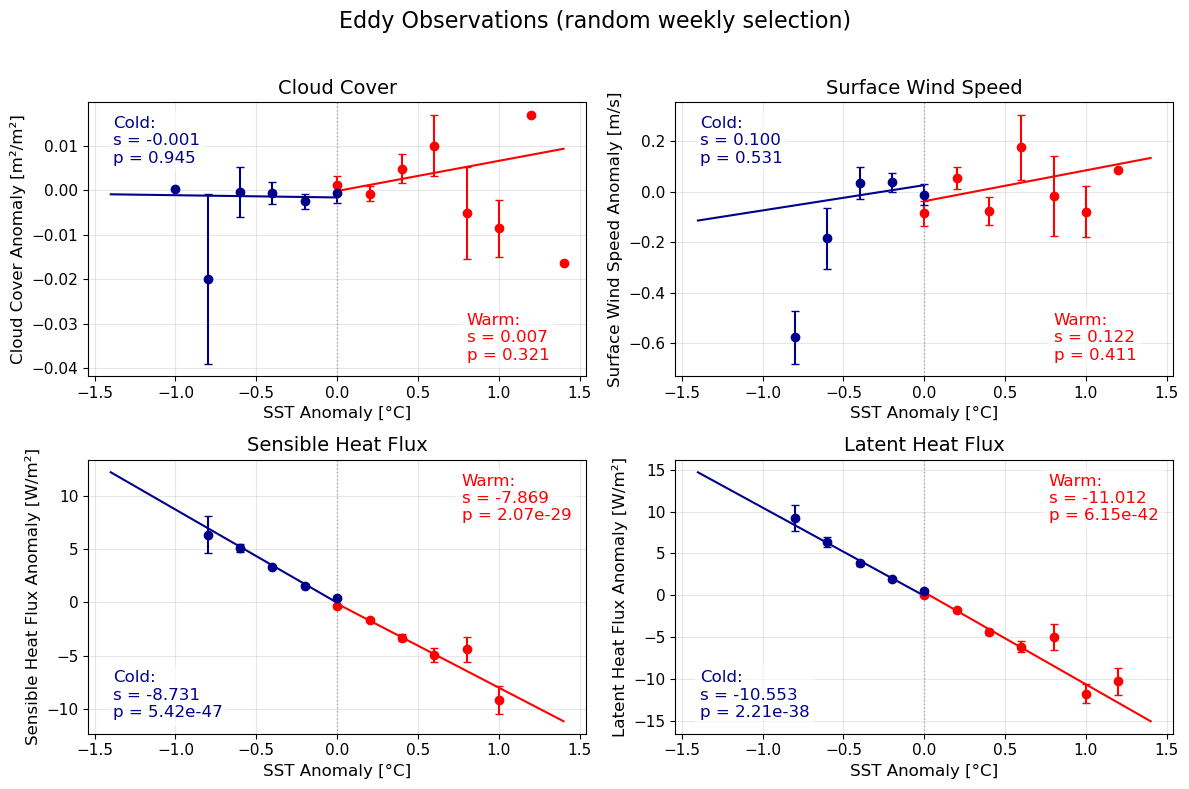

In [19]:
import matplotlib.pyplot as plt
import numpy as np

variables = ["clt", "sfcwind", "hfss", "hfls"]
titles = [
    "Cloud Cover Anomaly [m²/m²]",
    "Surface Wind Speed Anomaly [m/s]",
    "Sensible Heat Flux Anomaly [W/m²]",
    "Latent Heat Flux Anomaly [W/m²]"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    # --- Warm ---
    mean_warm = globals()[f"{var}_warm_mean_week"].values
    sem_warm  = globals()[f"{var}_warm_sem_week"].values
    res_warm  = globals()[f"res_{var}_warm"]

    # --- Cold ---
    mean_cold = globals()[f"{var}_cold_mean_week"].values
    sem_cold  = globals()[f"{var}_cold_sem_week"].values
    res_cold  = globals()[f"res_{var}_cold"]

    # --- Binned means ---
    ax.errorbar(
        bin_centers, mean_warm, yerr=sem_warm,
        fmt="o", capsize=3, color="red", label="Warm"
    )
    ax.errorbar(
        bin_centers, mean_cold, yerr=sem_cold,
        fmt="o", capsize=3, color="darkblue", label="Cold"
    )

    # --- Regression lines ---
    # Split x-range at 0
    x_neg = np.linspace(bin_centers.min(), 0, 100)
    x_pos = np.linspace(0, bin_centers.max(), 100)
    
    # Cold (blue): only negative SST anomalies
    ax.plot(
        x_neg,
        res_cold.intercept + res_cold.slope * x_neg,
        color="darkblue", lw=1.5
    )
    
    # Warm (red): only positive SST anomalies
    ax.plot(
        x_pos,
        res_warm.intercept + res_warm.slope * x_pos,
        color="red", lw=1.5
    )


    # --- Text box placement ---
    if i < 2:  # TOP ROW
    # Cold (top-left)
        ax.text(
            0.05, 0.95,
            "Cold:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"p = {res_cold.pvalue:.3g}",
            transform=ax.transAxes,
            fontsize=12,
            color="darkblue",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # Warm (bottom-right)
        ax.text(
            0.76, 0.05,
            "Warm:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"p = {res_warm.pvalue:.3g}",
            transform=ax.transAxes,
            fontsize=12,
            color="red",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    else:  # BOTTOM ROW
    # Cold (bottom-left)
        ax.text(
            0.05, 0.05,
            "Cold:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"p = {res_cold.pvalue:.3g}",
            transform=ax.transAxes,
            fontsize=12,
            color="darkblue",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # Warm (top-right)
        ax.text(
            0.75, 0.95,
            "Warm:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"p = {res_warm.pvalue:.3g}",
            transform=ax.transAxes,
            fontsize=12,
            color="red",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )


    
    # --- Labels ---
    clean_title = titles[i].split("Anomaly")[0].strip()
    ax.axvline(0, color="gray", lw=1, ls=":", alpha=0.6)
    ax.set_title(clean_title, fontsize=14)
    ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)

    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=11)

    #if i == 0:
        #ax.legend(fontsize=11)

plt.suptitle("Eddy Observations (random weekly selection)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eddy_obs_allvars_sstbins_warm_cold.pdf", bbox_inches="tight")
plt.show()


In [21]:
def monte_carlo_weekly_linregress(ds, var, n_iter=1000, seed=None, min_points=3):
    
    rng = np.random.default_rng(seed)

    # Time binning
    time_vals = ds['time'].values
    time_min = time_vals.min()
    week_bin = ((time_vals - time_min) / np.timedelta64(1, 'D') // 7).astype(int)
    unique_weeks = np.unique(week_bin)

    slopes = []
    intercepts = []
    rvalues = []
    pvalues = []
    stderrs = []

    # NEW: placeholders for diagnostics
    qq_residuals = None
    qq_fitted = None

    n_skipped = 0

    for _ in range(n_iter):
        selected_indices = []

        for w in unique_weeks:
            indices_in_bin = np.where(week_bin == w)[0]
            if len(indices_in_bin) == 0:
                continue
            selected_indices.append(rng.choice(indices_in_bin))

        if len(selected_indices) < min_points:
            n_skipped += 1
            continue

        ds_sample = ds.isel(obs=selected_indices)

        x = ds_sample['dif_sst'].values
        y = ds_sample[var].values

        # remove NaNs
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if len(x) < min_points or np.std(x) == 0:
            n_skipped += 1
            continue

        res = linregress(x, y)

        if np.isnan(res.slope):
            n_skipped += 1
            continue

        # store regression results
        slopes.append(res.slope)
        intercepts.append(res.intercept)
        rvalues.append(res.rvalue)
        pvalues.append(res.pvalue)
        stderrs.append(res.stderr)

        # =========================
        # STORE ONE DIAGNOSTIC SET
        # =========================
        if qq_residuals is None:
            y_pred = res.intercept + res.slope * x
            qq_residuals = y - y_pred
            qq_fitted = y_pred

    all_results = {
        'slope': np.array(slopes),
        'intercept': np.array(intercepts),
        'rvalue': np.array(rvalues),
        'pvalue': np.array(pvalues),
        'stderr': np.array(stderrs),
    }

    results_mean = {k: np.nanmean(v) for k, v in all_results.items()}
    results_std = {k: np.nanstd(v) for k, v in all_results.items()}

    return results_mean, results_std, all_results


In [23]:
def bootstrap_ci(values, ci=95):
    """
    Percentile bootstrap confidence interval.
    """
    alpha = 100 - ci
    lower = np.percentile(values, alpha / 2)
    upper = np.percentile(values, 100 - alpha / 2)
    return lower, upper


In [26]:
mean_clt_warm, std_clt_warm, all_clt_warm = monte_carlo_weekly_linregress(edso1_clt_q75_e20_warm, "dif_clt", n_iter=1000, seed=50)
mean_clt_cold, std_clt_cold, all_clt_cold = monte_carlo_weekly_linregress(edso1_clt_q75_e20_cold, "dif_clt", n_iter=1000, seed=50)

mean_hfls_warm, std_hfls_warm, all_hfls_warm = monte_carlo_weekly_linregress(edso1_hfls_q75_e20_warm, "dif_hfls", n_iter=1000, seed=50)
mean_hfls_cold, std_hfls_cold, all_hfls_cold = monte_carlo_weekly_linregress(edso1_hfls_q75_e20_cold, "dif_hfls", n_iter=1000, seed=50)

mean_hfss_warm, std_hfss_warm, all_hfss_warm = monte_carlo_weekly_linregress(edso1_hfss_q75_e20_warm, "dif_hfss", n_iter=1000, seed=50)
mean_hfss_cold, std_hfss_cold, all_hfss_cold = monte_carlo_weekly_linregress(edso1_hfss_q75_e20_cold, "dif_hfss", n_iter=1000, seed=50)

mean_sfcwind_warm, std_sfcwind_warm, all_sfcwind_warm = monte_carlo_weekly_linregress(edso1_sfcwind_q75_e20_warm, "dif_sfcwind", n_iter=1000, seed=50)
mean_sfcwind_cold, std_sfcwind_cold, all_sfcwind_cold = monte_carlo_weekly_linregress(edso1_sfcwind_q75_e20_cold, "dif_sfcwind", n_iter=1000, seed=50)

In [72]:
slope_ci_clt_warm = bootstrap_ci(all_clt_warm['slope'], ci=95)
slope_ci_clt_cold = bootstrap_ci(all_clt_cold['slope'], ci=95)

slope_ci_hfls_warm = bootstrap_ci(all_hfls_warm['slope'], ci=95)
slope_ci_hfls_cold = bootstrap_ci(all_hfls_cold['slope'], ci=95)

slope_ci_hfss_warm = bootstrap_ci(all_hfss_warm['slope'], ci=95)
slope_ci_hfss_cold = bootstrap_ci(all_hfss_cold['slope'], ci=95)

slope_ci_sfcwind_warm = bootstrap_ci(all_sfcwind_warm['slope'], ci=95)
slope_ci_sfcwind_cold = bootstrap_ci(all_sfcwind_cold['slope'], ci=95)

In [75]:
print(f"Mean slope: {mean_clt_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_warm[0]:.3f}, {slope_ci_clt_warm[1]:.3f}]")
print(f"Mean slope: {mean_clt_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_cold[0]:.3f}, {slope_ci_clt_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfls_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_warm[0]:.3f}, {slope_ci_hfls_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfls_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_cold[0]:.3f}, {slope_ci_hfls_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfss_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_warm[0]:.3f}, {slope_ci_hfss_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfss_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_cold[0]:.3f}, {slope_ci_hfss_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_sfcwind_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_warm[0]:.3f}, {slope_ci_sfcwind_warm[1]:.3f}]")
print(f"Mean slope: {mean_sfcwind_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_cold[0]:.3f}, {slope_ci_sfcwind_cold[1]:.3f}]")

Mean slope: 0.012
95% bootstrap CI: [-0.000, 0.024]
Mean slope: 0.001
95% bootstrap CI: [-0.014, 0.016]

Mean slope: -10.049
95% bootstrap CI: [-11.784, -8.355]
Mean slope: -11.107
95% bootstrap CI: [-12.651, -9.582]

Mean slope: -8.803
95% bootstrap CI: [-10.310, -7.500]
Mean slope: -9.490
95% bootstrap CI: [-10.765, -8.181]

Mean slope: 0.105
95% bootstrap CI: [-0.180, 0.393]
Mean slope: 0.048
95% bootstrap CI: [-0.277, 0.373]


In [30]:
from scipy.stats import ttest_ind

tstat, pval = ttest_ind(all_clt_warm["slope"], all_clt_cold["slope"], equal_var=False)
print("Welch t-statistic:", tstat)
print("p-value:", pval)

tstat_hfls, pval_hfls = ttest_ind(all_hfls_warm["slope"], all_hfls_cold["slope"], equal_var=False)
print("Welch t-statistic:", tstat_hfls)
print("p-value:", pval_hfls)

tstat_hfss, pval_hfss = ttest_ind(all_hfss_warm["slope"], all_hfss_cold["slope"], equal_var=False)
print("Welch t-statistic:", tstat_hfss)
print("p-value:", pval_hfss)

tstat_sfcwind, pval_sfcwind = ttest_ind(all_sfcwind_warm["slope"], all_sfcwind_cold["slope"], equal_var=False)
print("Welch t-statistic:", tstat_sfcwind)
print("p-value:", pval_sfcwind)

Welch t-statistic: 32.38242597632526
p-value: 1.4782039208150835e-183
Welch t-statistic: 28.21696740730593
p-value: 2.0023912206828998e-147
Welch t-statistic: 22.660466703600633
p-value: 2.6850446151290044e-101
Welch t-statistic: 8.161077661064901
p-value: 5.855570771432714e-16


In [31]:
def cohens_d_unequal(a, b):
    m1, m2 = np.mean(a), np.mean(b)
    s1, s2 = np.var(a, ddof=1), np.var(b, ddof=1)
    sd_avg = np.sqrt((s1 + s2) / 2)
    return (m1 - m2) / sd_avg

d = cohens_d_unequal(all_clt_warm["slope"], all_clt_cold["slope"])
d_hfls = cohens_d_unequal(all_hfls_warm["slope"], all_hfls_cold["slope"])
d_hfss = cohens_d_unequal(all_hfss_warm["slope"], all_hfss_cold["slope"])
d_sfcwind = cohens_d_unequal(all_sfcwind_warm["slope"], all_sfcwind_cold["slope"])

print("Cohen's d (unequal variances):", d)
print("Cohen's d (unequal variances):", d_hfls)
print("Cohen's d (unequal variances):", d_hfss)
print("Cohen's d (unequal variances):", d_sfcwind)

Cohen's d (unequal variances): 1.4481861151883653
Cohen's d (unequal variances): 1.261901144832641
Cohen's d (unequal variances): 1.0134068790224318
Cohen's d (unequal variances): 0.36497448839592217


In [32]:
obs_diff = np.mean(all_clt_warm["slope"]) - np.mean(all_clt_cold["slope"])
boot = []
for _ in range(10000):
    boot_warm = np.random.choice(all_clt_warm["slope"], size=len(all_clt_warm["slope"]), replace=True)
    boot_cold = np.random.choice(all_clt_cold["slope"], size=len(all_clt_cold["slope"]), replace=True)
    boot.append(np.mean(boot_warm) - np.mean(boot_cold))

ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print("Observed mean difference:", obs_diff)
print("95% CI:", ci_low, ci_high)


Observed mean difference: 0.010349380982214156
95% CI: 0.009725560746826071 0.010958656976581478


In [33]:
obs_diff_hfls = np.mean(all_hfls_warm["slope"]) - np.mean(all_hfls_cold["slope"])

boot_hfls = []
for _ in range(10000):
    boot_warm_hfls = np.random.choice(all_hfls_warm["slope"], size=len(all_hfls_warm["slope"]), replace=True)
    boot_cold_hfls = np.random.choice(all_hfls_cold["slope"], size=len(all_hfls_cold["slope"]), replace=True)
    boot_hfls.append(np.mean(boot_warm_hfls) - np.mean(boot_cold_hfls))

ci_low_hfls, ci_high_hfls = np.percentile(boot_hfls, [2.5, 97.5])

print("Observed mean difference:", obs_diff_hfls)
print("95% CI:", ci_low_hfls, ci_high_hfls)

Observed mean difference: 1.058773360073637
95% CI: 0.986335884172286 1.1321005286499664


In [34]:
obs_diff_hfss = np.mean(all_hfss_warm["slope"]) - np.mean(all_hfss_cold["slope"])

boot_hfss = []
for _ in range(10000):
    boot_warm_hfss = np.random.choice(all_hfss_warm["slope"], size=len(all_hfss_warm["slope"]), replace=True)
    boot_cold_hfss = np.random.choice(all_hfss_cold["slope"], size=len(all_hfss_cold["slope"]), replace=True)
    boot_hfss.append(np.mean(boot_warm_hfss) - np.mean(boot_cold_hfss))

ci_low_hfss, ci_high_hfss = np.percentile(boot_hfss, [2.5, 97.5])

print("Observed mean difference:", obs_diff_hfss)
print("95% CI:", ci_low_hfss, ci_high_hfss)

Observed mean difference: 0.6869044926751524
95% CI: 0.6284211294456072 0.7455224545599366


In [35]:
obs_diff_sfcwind = np.mean(all_sfcwind_warm["slope"]) - np.mean(all_sfcwind_cold["slope"])

boot_sfcwind = []
for _ in range(10000):
    boot_warm_sfcwind = np.random.choice(all_sfcwind_warm["slope"], size=len(all_sfcwind_warm["slope"]), replace=True)
    boot_cold_sfcwind = np.random.choice(all_sfcwind_cold["slope"], size=len(all_sfcwind_cold["slope"]), replace=True)
    boot_sfcwind.append(np.mean(boot_warm_sfcwind) - np.mean(boot_cold_sfcwind))

ci_low_sfcwind, ci_high_sfcwind = np.percentile(boot_sfcwind, [2.5, 97.5])

print("Observed mean difference:", round(obs_diff_sfcwind, 3))
print("95% CI:", ci_low_sfcwind, ci_high_sfcwind)

Observed mean difference: 0.057
95% CI: 0.04362656859247158 0.07076824172773048


In [30]:
mean_clt_ac_warm, std_clt_ac_warm, all_clt_ac_warm = monte_carlo_weekly_linregress(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst > 0, drop = True), "dif_clt", n_iter=1000, seed=50)
mean_clt_ac_cold, std_clt_ac_cold, all_clt_ac_cold = monte_carlo_weekly_linregress(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst < 0, drop = True), "dif_clt", n_iter=1000, seed=50)
mean_clt_c_warm, std_clt_c_warm, all_clt_c_warm = monte_carlo_weekly_linregress(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst > 0, drop = True), "dif_clt", n_iter=1000, seed=50)
mean_clt_c_cold, std_clt_c_cold, all_clt_c_cold = monte_carlo_weekly_linregress(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst < 0, drop = True), "dif_clt", n_iter=1000, seed=50)

In [32]:
mean_hfls_ac_warm, std_hfls_ac_warm, all_hfls_ac_warm = monte_carlo_weekly_linregress(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfls", n_iter=1000, seed=50)
mean_hfls_ac_cold, std_hfls_ac_cold, all_hfls_ac_cold = monte_carlo_weekly_linregress(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfls", n_iter=1000, seed=50)
mean_hfls_c_warm, std_hfls_c_warm, all_hfls_c_warm = monte_carlo_weekly_linregress(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst > 0, drop = True), "dif_hfls", n_iter=1000, seed=50)
mean_hfls_c_cold, std_hfls_c_cold, all_hfls_c_cold = monte_carlo_weekly_linregress(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst < 0, drop = True), "dif_hfls", n_iter=1000, seed=50)

In [33]:
mean_hfss_ac_warm, std_hfss_ac_warm, all_hfss_ac_warm = monte_carlo_weekly_linregress(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfss", n_iter=1000, seed=50)
mean_hfss_ac_cold, std_hfss_ac_cold, all_hfss_ac_cold = monte_carlo_weekly_linregress(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfss", n_iter=1000, seed=50)
mean_hfss_c_warm, std_hfss_c_warm, all_hfss_c_warm = monte_carlo_weekly_linregress(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst > 0, drop = True), "dif_hfss", n_iter=1000, seed=50)
mean_hfss_c_cold, std_hfss_c_cold, all_hfss_c_cold = monte_carlo_weekly_linregress(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst < 0, drop = True), "dif_hfss", n_iter=1000, seed=50)

In [34]:
mean_sfcwind_ac_warm, std_sfcwind_ac_warm, all_sfcwind_ac_warm = monte_carlo_weekly_linregress(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind", n_iter=1000, seed=50)
mean_sfcwind_ac_cold, std_sfcwind_ac_cold, all_sfcwind_ac_cold = monte_carlo_weekly_linregress(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind", n_iter=1000, seed=50)
mean_sfcwind_c_warm, std_sfcwind_c_warm, all_sfcwind_c_warm = monte_carlo_weekly_linregress(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind", n_iter=1000, seed=50)
mean_sfcwind_c_cold, std_sfcwind_c_cold, all_sfcwind_c_cold = monte_carlo_weekly_linregress(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind", n_iter=1000, seed=50)

In [35]:
slope_ci_clt_ac_warm = bootstrap_ci(all_clt_ac_warm['slope'], ci=95)
slope_ci_clt_ac_cold = bootstrap_ci(all_clt_ac_cold['slope'], ci=95)
slope_ci_clt_c_warm = bootstrap_ci(all_clt_c_warm['slope'], ci=95)
slope_ci_clt_c_cold = bootstrap_ci(all_clt_c_cold['slope'], ci=95)

slope_ci_hfls_ac_warm = bootstrap_ci(all_hfls_ac_warm['slope'], ci=95)
slope_ci_hfls_ac_cold = bootstrap_ci(all_hfls_ac_cold['slope'], ci=95)
slope_ci_hfls_c_warm = bootstrap_ci(all_hfls_c_warm['slope'], ci=95)
slope_ci_hfls_c_cold = bootstrap_ci(all_hfls_c_cold['slope'], ci=95)

slope_ci_hfss_ac_warm = bootstrap_ci(all_hfss_ac_warm['slope'], ci=95)
slope_ci_hfss_ac_cold = bootstrap_ci(all_hfss_ac_cold['slope'], ci=95)
slope_ci_hfss_c_warm = bootstrap_ci(all_hfss_c_warm['slope'], ci=95)
slope_ci_hfss_c_cold = bootstrap_ci(all_hfss_c_cold['slope'], ci=95)

slope_ci_sfcwind_ac_warm = bootstrap_ci(all_sfcwind_ac_warm['slope'], ci=95)
slope_ci_sfcwind_ac_cold = bootstrap_ci(all_sfcwind_ac_cold['slope'], ci=95)
slope_ci_sfcwind_c_warm = bootstrap_ci(all_sfcwind_c_warm['slope'], ci=95)
slope_ci_sfcwind_c_cold = bootstrap_ci(all_sfcwind_c_cold['slope'], ci=95)

In [37]:
print(f"Mean slope: {mean_clt_ac_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_ac_warm[0]:.3f}, {slope_ci_clt_ac_warm[1]:.3f}]")
print(f"Mean slope: {mean_clt_ac_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_ac_cold[0]:.3f}, {slope_ci_clt_ac_cold[1]:.3f}]")
print(f"Mean slope: {mean_clt_c_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_c_warm[0]:.3f}, {slope_ci_clt_c_warm[1]:.3f}]")
print(f"Mean slope: {mean_clt_c_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_c_cold[0]:.3f}, {slope_ci_clt_c_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfls_ac_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_ac_warm[0]:.3f}, {slope_ci_hfls_ac_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfls_ac_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_ac_cold[0]:.3f}, {slope_ci_hfls_ac_cold[1]:.3f}]")
print(f"Mean slope: {mean_hfls_c_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_c_warm[0]:.3f}, {slope_ci_hfls_c_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfls_c_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_c_cold[0]:.3f}, {slope_ci_hfls_c_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfss_ac_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_ac_warm[0]:.3f}, {slope_ci_hfss_ac_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfss_ac_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_ac_cold[0]:.3f}, {slope_ci_hfss_ac_cold[1]:.3f}]")
print(f"Mean slope: {mean_hfss_c_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_c_warm[0]:.3f}, {slope_ci_hfss_c_warm[1]:.3f}]")
print(f"Mean slope: {mean_hfss_c_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_c_cold[0]:.3f}, {slope_ci_hfss_c_cold[1]:.3f}]")
print()
print(f"Mean slope: {mean_sfcwind_ac_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_ac_warm[0]:.3f}, {slope_ci_sfcwind_ac_warm[1]:.3f}]")
print(f"Mean slope: {mean_sfcwind_ac_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_ac_cold[0]:.3f}, {slope_ci_sfcwind_ac_cold[1]:.3f}]")
print(f"Mean slope: {mean_sfcwind_c_warm['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_c_warm[0]:.3f}, {slope_ci_sfcwind_c_warm[1]:.3f}]")
print(f"Mean slope: {mean_sfcwind_c_cold['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_c_cold[0]:.3f}, {slope_ci_sfcwind_c_cold[1]:.3f}]")

Mean slope: 0.012
95% bootstrap CI: [0.001, 0.023]
Mean slope: -0.010
95% bootstrap CI: [-0.035, 0.017]
Mean slope: -0.001
95% bootstrap CI: [-0.031, 0.030]
Mean slope: 0.002
95% bootstrap CI: [-0.012, 0.019]

Mean slope: -10.103
95% bootstrap CI: [-11.755, -8.514]
Mean slope: -8.507
95% bootstrap CI: [-10.684, -6.225]
Mean slope: -5.541
95% bootstrap CI: [-8.999, -2.151]
Mean slope: -11.548
95% bootstrap CI: [-13.074, -10.026]

Mean slope: -8.792
95% bootstrap CI: [-10.091, -7.469]
Mean slope: -7.044
95% bootstrap CI: [-9.030, -5.082]
Mean slope: -6.405
95% bootstrap CI: [-10.203, -3.447]
Mean slope: -9.796
95% bootstrap CI: [-11.003, -8.509]

Mean slope: 0.103
95% bootstrap CI: [-0.176, 0.367]
Mean slope: 0.034
95% bootstrap CI: [-0.490, 0.574]
Mean slope: -0.664
95% bootstrap CI: [-1.269, -0.054]
Mean slope: 0.045
95% bootstrap CI: [-0.271, 0.369]
